In [6]:
import pandas as pd 
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
import plotly.express as px 
import pickle
import spacy 
import string
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from collections import Counter


In [7]:
# loading in data 
train=pd.read_csv('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/task-specific-datasets/banking_data/train.csv')
test=pd.read_csv('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/task-specific-datasets/banking_data/test.csv')
data=pd.concat([train,test]).reset_index()
data=data.drop(columns=['index','category'])

- Used SBERT_embedding.py file to get bert embeddings 
- Used TSNE_trans.py file to get data for USE embeddings and tsne data for BERT and USE data (2d and 3d)
- Used labels.py to get the KMeans labels for bert and use ( balanced and regular silhoutte score)
- Used bal_kmean.py file to get graphes for silhoutte score analysis between KMeans

In [8]:
 # 2 of the 4 embeddings mentioned in the article( USE and BERT)
use_embeddings = np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/use_embeddings.npy')
bert_embeddings= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/embedding.npy')
bert_model_regular_labels= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/bert_model_regular_labels.npy')
bert_model_balanced_labels= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/bert_model_balanced_labels.npy')
use_model_regular_labels= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/use_model_regular_labels.npy')
use_model_balanced_labels= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/use_model_balanced_labels.npy')

# Silhoute scores for finding best number of clusters for both BERT and USE embeddings

used bal_kmean.py file to create visuals 

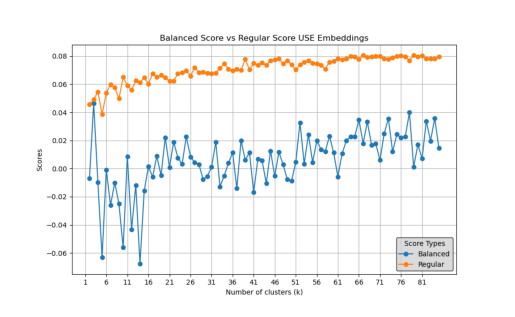

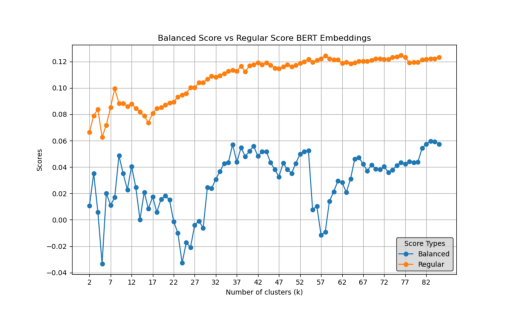

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread("/ocean/projects/cis240109p/mmarius/PNC_work/NLP/balance_sil_USE.png")
plt.axis('off')  
plt.imshow(img1)
plt.show()

img2 = mpimg.imread("/ocean/projects/cis240109p/mmarius/PNC_work/NLP/balance_sil_BERT.png")
plt.axis('off')  
plt.imshow(img2)
plt.show()

# Visualizing clusters from optimal k

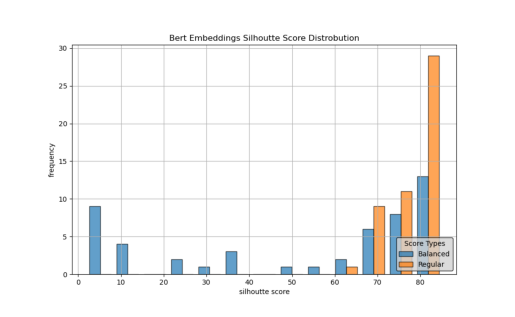

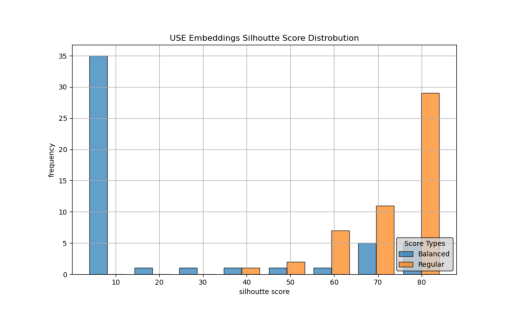

In [17]:
img3 = mpimg.imread("/ocean/projects/cis240109p/mmarius/PNC_work/NLP/distrobution_sil_Bert.png")
plt.axis('off')  
plt.imshow(img3)
plt.show()

img4 = mpimg.imread("/ocean/projects/cis240109p/mmarius/PNC_work/NLP/distrobution_sil_USE.png")
plt.axis('off')  
plt.imshow(img4)
plt.show()

# K's being used 
- Using 83 clusters for both bert and use regular 
- Using 81 for bert balanced 
- Using 3 for use balanced  

# Analysis so far

I can play with the lambda value some more (0.25->1 going by .25 for example) to possibly find the optimal number clusters silhoutte score. especially since USE balance is optimal at 3

Bert 
- when comparing the optimal number of clusters, the bert score regular comes closes to the actual number of groups that this model has

- The balanced scores comes close also but is a little over(if i run this 100 times a get a distributions, it should be in the same ball park)

USE
- The balanced score does a poor job with assigning these clusters or it's either super unstable( high standard deviation)
- the regular score is similar to the Bert scores for both balanced and imbalanced 


need to check bert also for stability 


# Creating topics for clusters 

In [18]:
data['bert_reg_label']=bert_model_regular_labels

# Testing

assigning pairs to documents ( Noun Verb pairing)

In [19]:
nlp = spacy.load("en_core_web_sm") # can change from sm to md or lg for better performance 

def extract_action_object_pairs(utterance):
    """Extract (action, object) pairs from an utterance using dependency parsing"""
    doc = nlp(utterance)
    pairs = []
    
    # Find direct objects and their governing verbs
    for token in doc:
        # Check if this token is a direct object
        if token.dep_ == "dobj":
            # The action is the head word (typically a verb)
            action = token.head.text
            # The object is the token itself (typically a noun)
            obj = token.text
            pairs.append((action, obj))
        

    if len(pairs)==0 and token == doc[-1]:
        
        pairs.append('None')
    
    return pairs

In [20]:
# getting count of nouns and verbs in document 
def n_v_pairings(documnet):
    doc=nlp(documnet)
    noun=[]
    verb=[]
    # Find direct objects and their governing verbs
    for token in doc:
    # for i in range(len(doc)):
        # Check if this token is a direct object
        if token.pos_ == "NOUN" or token.pos_ == 'PROPN':
            # The action is the head word (typically a verb)
            noun.append(token.lemma_.lower())
        if token.pos_ == "VERB":        # The object is the token itself (typically a noun)
            verb.append(token.lemma_.lower())
        
        if (len(noun)==0 or len(verb)==0) and token == doc[-1]:
        
            noun.append('None')
            verb.append('None')
    
    return(noun,verb)


In [21]:
# returns dic of noun's and there total count and verbs and there total count ( input should be filter based on cluster)
def n_v_counter(data):
    noun_counter = Counter()
    verb_counter = Counter()

# Flatten and process pairs
    for entry in data:
        noun, verb = entry
        for n in noun:
            noun_counter[n] += 1
        for v in verb:
            verb_counter[v] += 1
    noun_counter.pop("None",None) # removing none from dictonary
    verb_counter.pop("None",None) # removing none from dictonary
                
    return noun_counter, verb_counter

testing technique on cluster 19

In [22]:
ds=data[data['bert_reg_label']==19] # only testing on label 19
ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x)) # getting pairings
noun_freq, verb_freq = n_v_counter(ds['pairings']) # getting count of pairings


# noun most freq word
n_max_key = max(noun_freq, key=noun_freq.get)
n_max_value = noun_freq[n_max_key]
# verb most freq word 
v_max_key = max(verb_freq, key=verb_freq.get)
v_max_value = verb_freq[n_max_key]
# Get most common actions

print(f"{n_max_key}:{v_max_key}")


identity:verify


/tmp/ipykernel_2113973/2202865610.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))


applying process to whole dataset

In [23]:
data['bert_reg_topic']='None'
for i in np.unique(data['bert_reg_label']):
    # filtering to label 
    ds=data[data['bert_reg_label']==i]
    # getting pairings
    ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))
    # getting count of parings seperately 
    noun_freq, verb_freq = n_v_counter(ds['pairings'])
    

    # action most freq word
    n_sort=sorted(noun_freq.items() ,key= lambda x: x[1], reverse= True)
    v_sort=sorted(verb_freq.items() ,key= lambda x: x[1], reverse= True)

    # getting second and first most noun
    n1_key,_=n_sort[0]
    n2_key,_=n_sort[1]
    # getting second and first most verb

    v1_key,_=v_sort[0]
    v2_key,_=v_sort[1]
    

    # updating data set
    data['bert_reg_topic']=data.apply(lambda x: f"{n1_key}:{v1_key},{n2_key}:{v2_key}" if x['bert_reg_label'] == i else x['bert_reg_topic'], axis=1)



/tmp/ipykernel_2113973/1316359480.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))
/tmp/ipykernel_2113973/1316359480.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))
/tmp/ipykernel_2113973/1316359480.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [24]:
(np.unique(data['bert_reg_topic'])) 

array(['account:delete,service:close', 'account:open,age:have',
       'account:receive,money:get', 'account:top,apple:use',
       'account:transfer,money:use', 'address:change,detail:need',
       'app:exchange,currency:use', 'app:make,payment:be',
       'app:use,contactless:work', 'atm:charge,fee:use',
       'atm:get,cash:give', 'atm:use,card:get',
       'beneficiary:transfer,transfer:allow',
       'card:activate,activation:need', 'card:arrive,week:get',
       'card:cancel,payment:be', 'card:charge,fee:use',
       'card:decline,payment:try', 'card:expire,date:do',
       'card:expire,one:get', 'card:get,fee:have', 'card:get,limit:use',
       'card:get,us:live', 'card:get,work:order',
       'card:have,transaction:make', 'card:link,app:track',
       'card:steal,transaction:use', 'card:top,fee:charge',
       'card:top,up:verify', 'card:use,credit:accept',
       'card:use,use:tell', 'card:work,help:use',
       'cash:charge,fee:withdraw', 'cash:deposit,account:show',
       '

# Removing stop words since it clouds the model

In [25]:
# Updating pairing function to include stopwords 
def n_v_pairings(documnet):
    stop_words=list(nlp.Defaults.stop_words)
    stop_words.extend(['use','give','need','get','happen','like','want']) # these words appeard as topics and is clouding model without providing useful information
    doc=nlp(documnet)
    noun=[]
    verb=[]
    # Find direct objects and their governing verbs
    for token in doc:
    # for i in range(len(doc)):
        # Check if this token is a direct object
        if token.pos_ == "NOUN" or token.pos_ == 'PROPN':
            # The action is the head word (typically a verb)
            noun.append(token.lemma_.lower())
        if token.pos_ == "VERB":        # The object is the token itself (typically a noun)
            if token.lemma_.lower() in stop_words:
                continue
            else:
                verb.append(token.lemma_.lower())
        
        if (len(noun)==0 or len(verb)==0) and token == doc[-1]:
        
            noun.append('None')
            verb.append('None')
    
    return(noun,verb)

In [26]:
data['bert_reg_topic']='None'
for i in np.unique(data['bert_reg_label']):
    # filtering to label 
    ds=data[data['bert_reg_label']==i]
    # getting pairings
    ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))
    # getting count of parings seperately 
    noun_freq, verb_freq = n_v_counter(ds['pairings'])
    

    # action most freq word
    n_sort=sorted(noun_freq.items() ,key= lambda x: x[1], reverse= True)
    v_sort=sorted(verb_freq.items() ,key= lambda x: x[1], reverse= True)

    # getting second and first most noun
    n1_key,_=n_sort[0]
    n2_key,_=n_sort[1]
    n3_key,_=n_sort[2]
    # getting second and first most verb

    v1_key,_=v_sort[0]
    v2_key,_=v_sort[1]
    v3_key,_=v_sort[2]
    

    # updating data set
    data['bert_reg_topic']=data.apply(lambda x: f"{n1_key}:{v1_key},{n2_key}:{v2_key},{n3_key}:{v3_key}" if x['bert_reg_label'] == i else x['bert_reg_topic'], axis=1)



/tmp/ipykernel_2113973/1346545669.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))
/tmp/ipykernel_2113973/1346545669.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds['pairings']=ds['text'].apply(lambda x: n_v_pairings(x))
/tmp/ipykernel_2113973/1346545669.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

example of text 

In [28]:
(np.unique(data['bert_reg_topic'])) 

array(['transaction:receive,money:send,friend:arrive',
       'transfer:charge,fee:transfer,money:think',
       'transfer:decline,message:try,decline:check',
       'transfer:pende,account:wait,money:check',
       'transfer:transfer,account:wait,day:send',
       'transfer:try,account:fail,time:check',
       'up:verify,top:find,verification:tell',
       'withdrawal:pende,cash:withdraw,account:decline'], dtype=object)

# Based on this now we can manually label which pairs are anomaly or not 

# The anomaly topics are the topics or comments that 

3 levels

High priority (classified as 2)
- Top alert must look at ( fraud, extra money, things not appearing or working, unrecognized payment)

MID (classified as 1)
- Things that aren't so urgent but need to be looked at ( pending, card tracking, changing details )

Low (classified as 0)
- Things that you can live with not being answered ( questions or non urgent matters)


hard search 

In [30]:
l2=['account:receive,money:come,seller:return','app:revert,payment:check,cash:know',
    'app:work,contactless:try,phone:mug','atm:charge,fee:withdraw,withdrawal:know',
    'card:cancel,payment:work,money:revert','card:charge,fee:pay,payment:think',
    'card:decline,payment:try,time:work','card:steal,transaction:think,account:help',
    'cash:charge,fee:withdraw,withdrawal:think','cash:deposit,account:update,deposit:send',
    'cash:receive,amount:ask,money:try','debit:recognize,payment:dispute,account:set',
    'fee:charge,account:receive,money:notice','money:transfer,account:try,transfer:help',
    'money:transfer,account:update,transfer:disappear','passcode:reset,password:forget,app:work',
    'pay:work,google:pay,apple:help','payment:decline,account:pay,statement:know',
    'phone:steal,account:lose,yesterday:access','pin:find,card:locate,number:receive',
    'pin:unblock,time:block,account:enter','rate:look,exchange:think,payment:expect',
    'statement:charge,charge:pende,fee:come','transaction:cancel,transfer:help,account:reverse',
    'transaction:charge,charge:look,time:notice','transfer:decline,message:try,decline:check',
    'transfer:pende,account:wait,money:check',
    ]
l1=['account:delete,service:close,company:terminate','address:change,detail:update,adress:report',
    'atm:withdraw,cash:try,money:request','beneficiary:transfer,transfer:allow,money:deny',
    'card:arrive,week:receive,delivery:wait','card:expire,one:order,replacement:cost',
    'card:link,app:track,tracking:send','card:order,work:work,way:receive','card:work,help:lose,work:help',
    'card:work,limit:tell,work:order','detail:change,name:edit,account:update',
    'fund:come,source:verify,money:know','money:transfer,account:wait,transfer:send',
    'payment:pende,card:mean,transaction:know','rate:apply,exchange:buy,cash:charge',
    'refund:buy,item:refund,money:receive','refund:request,statement:miss,account:check',
    'top:pende,up:cancel,money:work','top:revert,up:work,problem:fail',
    'transaction:receive,money:send,friend:arrive','transfer:transfer,account:wait,day:send',
    'transfer:try,account:fail,time:check','up:verify,top:find,verification:tell','withdrawal:pende,cash:withdraw,account:decline']

based on tags/topic (Not being used)

In [31]:
level2=['charge','fee','block','deny','decline','steal','dispute','verify','forget','refund','fail','return']
level1=['try','change','withdraw','change','delete','recive','return','transfer','check','activate','cancel',
        'expire','order','help','recive','find','limit','pende']


- 2 is highest anomaly
- 1 is look at
- 0 is possibly ignore 

(basically queue or priority system)

In [32]:
def anomaly(topic): # anomaly based on pairs 

        # Split topic into key:value pairs
    values = [pair.split(':')[1] for pair in topic.split(',') if ':' in pair]

    for word in level2:
        if word in values:
            return 'High'
    for word in level1:
        if word in values:
            return 'Mid'
    return 'Low'


def anomaly_2(topic): # anomaly based on topics

    if topic in l2:
            return 'High'
    if topic in l1:
            return 'Mid'
    return 'Low'





saving labels for streamlit

In [33]:
data['anomaly']=data['bert_reg_topic'].apply(lambda x: anomaly_2(x))
# saving labels 
np.save('label_topics.npy',data['bert_reg_topic'])
np.save('anomaly_labels.npy',data['anomaly'])

# Feature analysis 

In [34]:
data['anomaly'].value_counts()

anomaly
Low     4466
Mid     4367
High    4250
Name: count, dtype: int64

# Making 3d plots BERT to visualize

In [35]:
data_ts3= np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE_3.npy')
# assigned bert tsne embeeddings
data['F1']=data_ts3[:,0]
data['F2']=data_ts3[:,1]
data['F3']=data_ts3[:,2]

dic={}

for label in np.unique(data['bert_reg_label']):
    
    text=data['text'][data['bert_reg_label']==label]
    dic[label]=(len(text)) # making list of total datapoints for each class

data['count_bert_reg']= data['bert_reg_label'].apply(lambda x: dic[x])

In [36]:
fig = px.scatter_3d(data, x='F1', y='F2', z='F3',color='bert_reg_topic',hover_data=['text','count_bert_reg','bert_reg_topic'], opacity=0.7)

fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D Kmeans(Regular)-TSNE labeled on BERT Embeddings")
fig.write_html("Bert_Reg_KMean.html")

In [37]:
fig = px.scatter_3d(data, x='F1', y='F2', z='F3',color='anomaly',hover_data=['text','bert_reg_topic'], opacity=0.7)

fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D Kmeans(Regular)-TSNE labeled on Anomaly ")
fig.write_html("Anomaly_KMean.html")

# Making live prediction 

TSNE has an issue where if you want to get the coordinates of a new data point, you'll have to recalculate the entire dataset including that one new point.

This is becasue T-SNE learns a non-parametric mapping so it's not learning a specific function to where u can map any input into this new space.

For example if I ploted half of the data with TSNE, there cordinates will be completely differnt than if I mapped them along with the full dataset. Hence recalculate.


## Reference 

https://stackoverflow.com/questions/41430233/adding-new-points-to-the-t-sne-model